In [2]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

data_dir = Path('../data/raw/gb_wildlife_dataset')
classes = [d.name for d in data_dir.iterdir() if d.is_dir()]

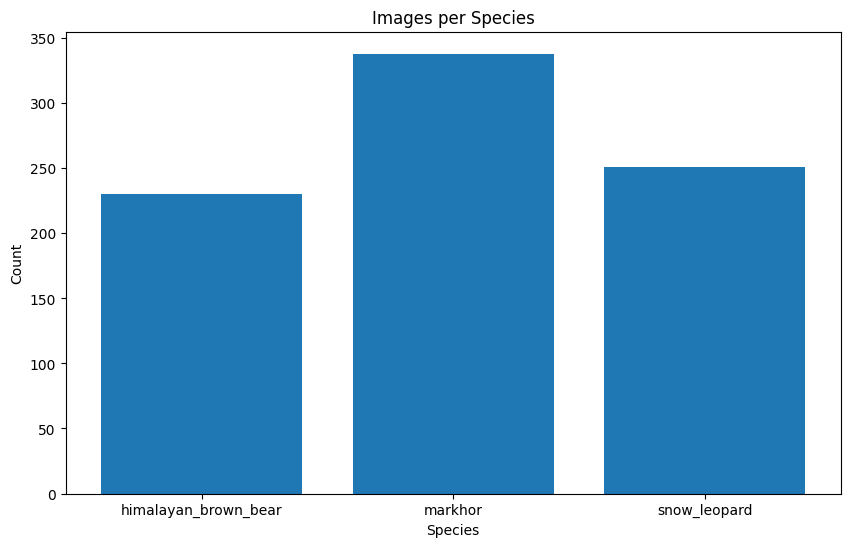

In [3]:
class_counts = {}
for c in classes:
    class_counts[c] = len(list((data_dir / c).glob('*.*')))

plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Images per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

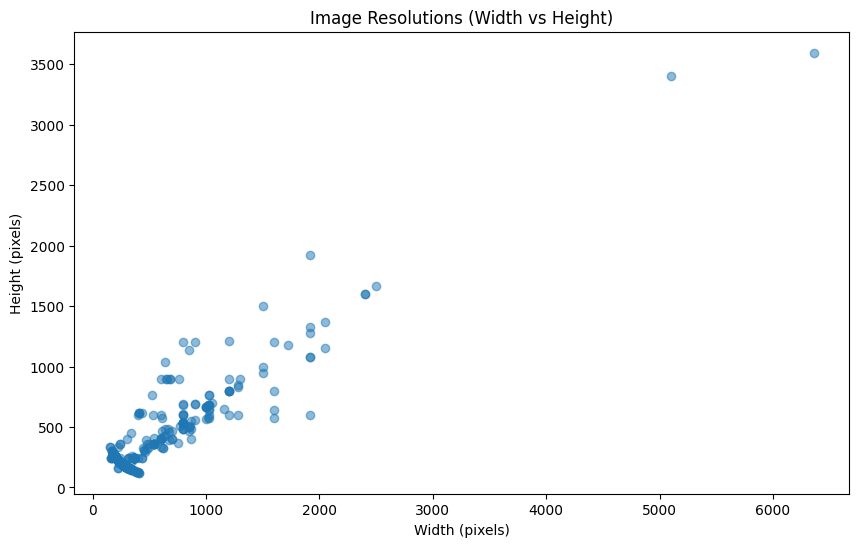

In [4]:
widths = []
heights = []

for c in classes:
    images = list((data_dir / c).glob('*.*'))
    for img_path in images:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            pass

plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.5)
plt.title('Image Resolutions (Width vs Height)')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.show()

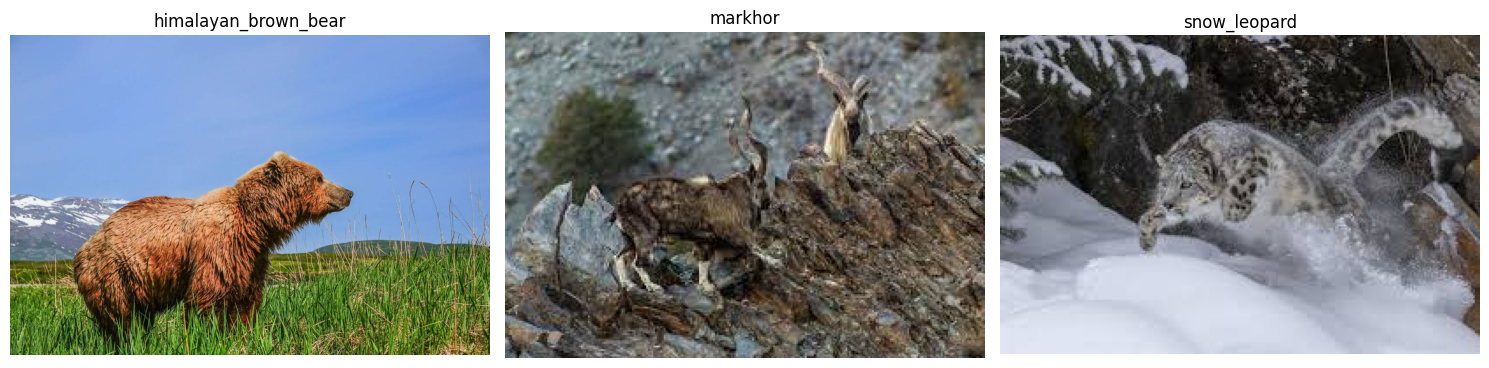

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, c in zip(axes, classes):
    images = list((data_dir / c).glob('*.*'))
    if images:
        sample_path = random.choice(images)
        img = Image.open(sample_path)
        ax.imshow(img)
        ax.set_title(c)
        ax.axis('off')

plt.tight_layout()
plt.show()